#Taller #1
Juan Pablo Betancur Zuluaga

Santiago Pareja Pareja

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sci
from ipywidgets import interact
import control as sc
import ipywidgets as widgets

## 1


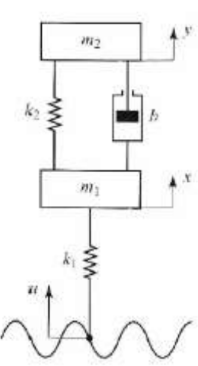

#### **Solución por Lagrange**
---
La entrada del sistema es un movimiento del suelo, que se modela como una señal senoidal.

$Q=Asin(ωt)$

Definimos como variables el desplazamiento de cada masa: $x$ para la masa inferior y $y$ para la superior.

$q = \begin{bmatrix} x\\ y \end{bmatrix}$

$q̇ = \begin{bmatrix} ẋ\\ ẏ \end{bmatrix}$

El amortiguador depende de la velocidad relativa entre las masas, no de la posición.

$P=0.5b(ẏ-ẋ)^2$

Cada resorte tiene energía potencia:
- $k_1$: Deformación entre el suelo y $m_1$.
- $k_2$: Deformación entre las masas.

$U=0.5k_1(x-u)^2+0.5k_2(y-x)^2$

Cada masa tiene energía cinética.

$T=0.5m_1ẋ^2+0.5m_2ẏ^2$

El Lagrangiano es simplemente la diferencia entre energía cinética y potencial.

$L=T-U=0.5m_1ẋ^2+0.5m_2ẏ^2-0.5k_1(x-u)^2-0.5k_2(y-x)^2$

---
#### **Para x:**
-
Aplicando
$$
\frac{d}{dt}(\frac{∂L}{∂ẋ})-\frac{∂L}{∂x}+\frac{∂P}{∂ẋ}=0
$$

Nos da como resultado:

$$
m_1ẍ+k_1x-k_1u+bẋ-bẏ=0
$$

---
#### **Para y:**
-
Aplicando
$$
\frac{d}{dt}(\frac{∂L}{∂ẏ})-\frac{∂L}{∂y}+\frac{∂P}{∂xẏ}=0
$$

Nos da como resultado:

$$
m_2ÿ+k_2y-k_2x+b*ẏ-bẋ=0
$$

In [2]:
def LagrangeP1(w, t, k1, k2, m1, m2, b, A, W):
    dw = np.zeros(4)

    u = A * np.sin(W * t)

    dw[0] = w[1]
    dw[1] = (1/m1)*(-b*(w[1] - w[3]) - (k1 + k2)*w[0] + k2*w[2] + k1*u)
    dw[2] = w[3]
    dw[3] = (1/m2)*(-b*(w[3] - w[1]) - k2*(w[2] - w[0]))

    return dw

In [3]:
@interact(m1=(0.1,20,0.1),m2=(0.1,20,0.1),
          k1=(1, 100, 1),k2=(1, 100, 1),
          A=(0, 5, 0.1), W=(0,20,0.5),
          b=(0, 20, 0.5),
          x0=(-2,2,0.1), xp0=(-5,5,0.5),
          y0=(0,4,0.1), yp0=(-5,5,0.5)
          )
def simulacion(m1=1, m2=1, k1=20, k2=15, A=1, W=5, b=1, x0=0, xp0=0, y0=0.5, yp0=0):

    t = np.linspace(0, 10, 1000)
    w0 = [x0, xp0, y0, yp0]

    sol = sci.integrate.odeint(LagrangeP1, w0, t, args=(k1, k2, m1, m2, b, A, W))

    x = sol[:,0]
    y = sol[:,2]

    plt.figure(figsize=(8,4))
    plt.plot(t, x, label='x(t)')
    plt.plot(t, y, label='y(t)')
    plt.title("Sistema de 2 masas acopladas")
    plt.xlabel("Tiempo")
    plt.ylabel("Posición")
    plt.legend()
    plt.grid()
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='m1', max=20.0, min=0.1), FloatSlider(value=1.0, desc…

## 2

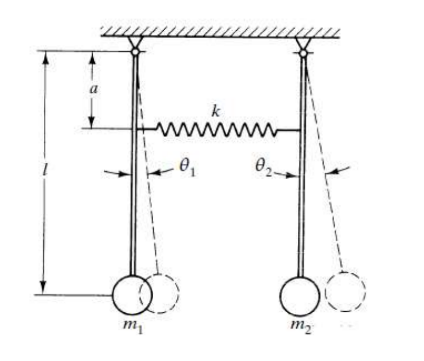

#### **Solución por Lagrange**
---
Definimos como coordenadas generalizadas los ángulos del sistema:

$q = \begin{bmatrix} x \ \theta \end{bmatrix}$

$\dot{q} = \begin{bmatrix} \dot{x} \ \dot{\theta} \end{bmatrix}$

No hay terminos de disipación, por lo tanto podemos proceder a despejar el resto de nuestras variables de interes.

Cada masa tiene energía cinética:

$T = \frac{1}{2}m_1 l^2 \dot{\theta} + \frac{1}{2}m_2 l^2 \dot{\theta}$

La energía potencial depende de la altura de cada masa y de la elongación del resorte:

$U = m_1 g h_1 + m_2 g h_2 + \frac{1}{2} k x^2$

La elongación del resorte depende de como se descompone geometricamente ambos pendulos, por lo que podemos observar que, la distancia $a$ corresponde a la longitud desde el punto de equilibrio hasta el resorte y nos interesamos en su componente en X tanto para $m_1$ como para $m_2$, por lo tanto:

$x_1 = a sin(\theta_1)$ $x_2 = a sin(\theta_2)$

Dado que el resorte se elonga o contrae acorde a estas dos, se puede entender que depende de la diferencia de ambos terminos

$x = a sin(\theta_1) - a sin(\theta_2)$

$x = a(sin(\theta_1) - sin(\theta_2))$

Ahora para la altura, sabemos que depende de la longitud y del angulo tambien con respecto al pendulo, bajo esta consideración, trazamos las componentes paralelas y perpendiculares al punto de equilibrio y llegamos a que:

$h = l - lcos(\theta)$

Dejandonos entonces con la expresión final:

$U = m_1 g (l - lcos(\theta_1)) + m_2 g (l - lcos(\theta_2)) + \frac{1}{2} k a^2 (sin(\theta_1) - sin(\theta_2))^2$

Utilizando las aproximaciones de ángulos pequeños:

$sin(\theta) = \theta$

$cos(\theta) = 1 - \frac{\theta^2}{2}$

Obtenemos como expresiones finales para el lagrangiano:

$\mathcal{L} = \frac{1}{2} m_1 l^2 \dot{\theta}_1^2 + \frac{1}{2} m_2 l^2 \dot{\theta}_2^2 - m_1 g l (1 - \cos\theta_1) - m_2 g l (1 - \cos\theta_2) - \frac{1}{2} k a^2 (\theta_2 - \theta_1)^2$

Haciendo las respectivas derivadas obtenemos como final los sistemas:

---

#### **Para $\theta_1$**
--

\begin{equation}
m_1 l^2 \ddot{\theta}_1 + m_1 g l \theta_1 + k a^2 (\theta_1 - \theta_2) = 0
\end{equation}

---

#### **Para $\theta_2$**
--

\begin{equation}
m_2 l^2 \ddot{\theta}_2 + m_2 g l \theta_2 + k a^2 (\theta_2 - \theta_1) = 0
\end{equation}

#### Frecuencias naturales del sistema

Suponiendo soluciones armónicas:

$$
\theta_1 = A_1 e^{i\omega t}, \quad \theta_2 = A_2 e^{i\omega t}
$$

Sustituyendo en el sistema:

$$
m_1 l^2 \ddot{\theta}_1 + m_1 g l \theta_1 + k a^2(\theta_1 - \theta_2) = 0
$$

$$
m_2 l^2 \ddot{\theta}_2 + m_2 g l \theta_2 + k a^2(\theta_2 - \theta_1) = 0
$$

Usando:

$$
\ddot{\theta} = -\omega^2 \theta
$$

Se obtiene:

$$
(-m_1 l^2 \omega^2 + m_1 g l + k a^2)\theta_1 - k a^2 \theta_2 = 0
$$

$$
- k a^2 \theta_1 + (-m_2 l^2 \omega^2 + m_2 g l + k a^2)\theta_2 = 0
$$

Para soluciones no triviales:

$$
\det
\begin{pmatrix}
-m_1 l^2 \omega^2 + m_1 g l + k a^2 & -k a^2 \\
-k a^2 & -m_2 l^2 \omega^2 + m_2 g l + k a^2
\end{pmatrix}
= 0
$$

---

##### Caso particular: \( m_1 = m_2 = m \)

Las frecuencias naturales son:

##### Modo en fase
$$
\omega_1^2 = \frac{g}{l}
$$

##### Modo fuera de fase
$$
\omega_2^2 = \frac{g}{l} + \frac{2k a^2}{m l^2}
$$

---

##### Resultado final

$$
\omega_1 = \sqrt{\frac{g}{l}}, \quad
\omega_2 = \sqrt{\frac{g}{l} + \frac{2k a^2}{m l^2}}
$$

In [4]:
# Sistema de ecuaciones
def LagrangeP2(w, t, m1, m2, k, l, a, g):

    f = np.zeros(4)

    # Variables
    x1 = w[0]  # θ1
    x3 = w[1]  # θ1'
    x2 = w[2]  # θ2
    x4 = w[3]  # θ2'

    # Ecuaciones de primer orden
    f[0] = x3
    f[2] = x4

    f[1] = -(g/l)*x1 - (k*a**2)/(m1*l**2)*(x1 - x2)
    f[3] = -(g/l)*x2 - (k*a**2)/(m2*l**2)*(x2 - x1)

    return f

In [5]:
@interact(
    m1=(0.1,20,0.1),
    m2=(0.1,20,0.1),
    k=(0.1,50,0.5),
    l=(0.5,5,0.1),
    a=(0.1,2,0.1),
    x0=(-1,1,0.1),
    xp0=(-5,5,0.5),
    y0=(-1,1,0.1),
    yp0=(-5,5,0.5)
)
def simulacion(m1=1, m2=1, k=10, l=1, a=0.5,
               x0=0.2, xp0=0, y0=0, yp0=0):

    g = 9.81

    t = np.linspace(0, 20, 1000)

    # w = [θ1, θ1', θ2, θ2']
    w0 = [x0, xp0, y0, yp0]

    sol = sci.integrate.odeint(
        LagrangeP2,
        w0,
        t,
        args=(m1, m2, k, l, a, g)
    )

    theta1 = sol[:,0]
    theta2 = sol[:,2]

    plt.figure(figsize=(8,4))
    plt.plot(t, theta1, label=r'$\theta_1(t)$')
    plt.plot(t, theta2, label=r'$\theta_2(t)$')
    plt.title("Péndulos acoplados")
    plt.xlabel("Tiempo")
    plt.ylabel("Ángulo")
    plt.legend()
    plt.grid()
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='m1', max=20.0, min=0.1), FloatSlider(value=1.0, desc…

## 3

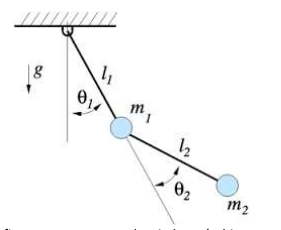

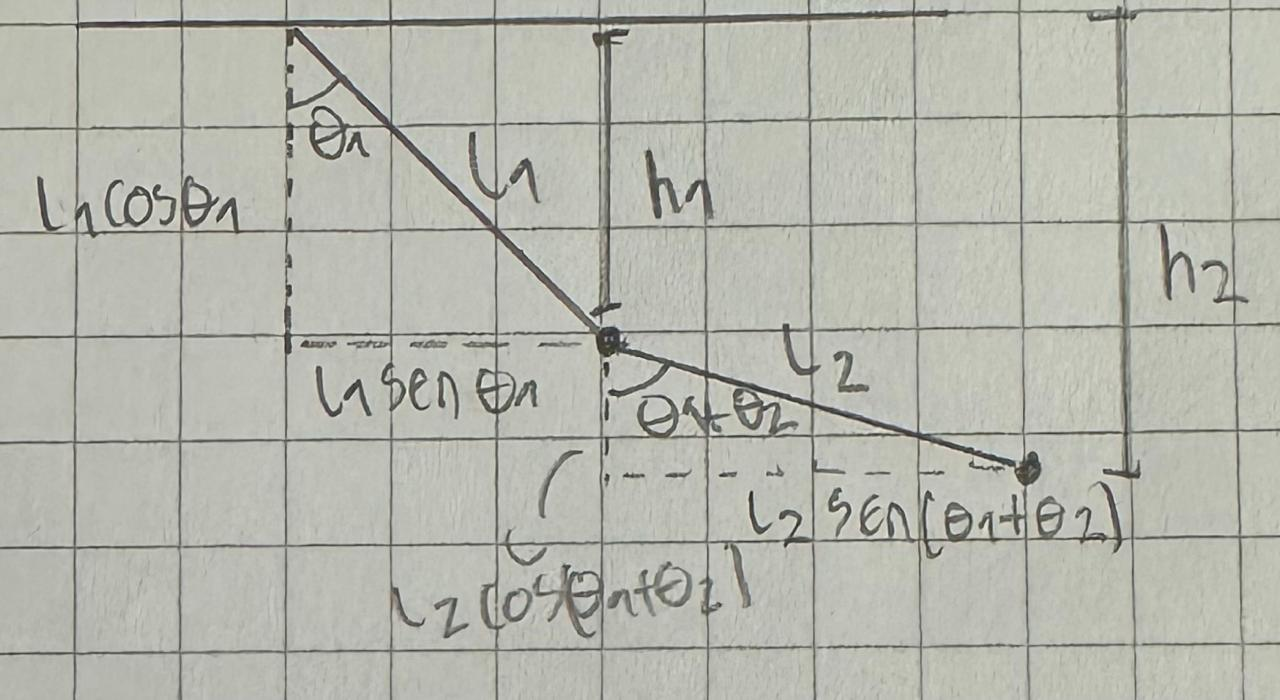

#### **Solución por Lagrange**
---
Definimos como coordenadas generalizadas los ángulos del sistema:

$q = \begin{bmatrix} \theta_1 \ \theta_2 \end{bmatrix}$

$\dot{q} = \begin{bmatrix} \dot{\theta}_1 \ \dot{\theta}_2 \end{bmatrix}$

No existen fuerzas no conservativas:

$Q = 0$


La energía potencial depende de la altura de cada masa:

$U = m_1 g h_1 + m_2 g h_2$

Donde:

$h_1 = -l_1 \cos(\theta_1)$

$h_2 = -l_1 \cos(\theta_1) - l_2 \cos(\theta_1 + \theta_2)$

Entonces:

$U = -(m_1+m_2) g l_1 \cos(\theta_1) - m_2 g l_2 \cos(\theta_1+\theta_2)$

Cada masa tiene energía cinética:

$T = 0.5m_1v_1^2 + 0.5m_2v_2^2$

**$v_1$:**

- $x_1 = l_1 \sin(\theta_1)$

- $y_1 = -l_1 \cos(\theta_1)$

- $\dot{x}_1 = l_1 \dot{\theta}_1 \cos(\theta_1)$

- $\dot{y}_1 = l_1 \dot{\theta}_1 \sin(\theta_1)$

- $v_1^2 = l_1^2 \dot{\theta}_1^2$

**$v_2$:**

- $x_2 = l_1 \sin(\theta_1) + l_2 \sin(\theta_1+\theta_2)$
- $y_2 = -l_1 \cos(\theta_1) - l_2 \cos(\theta_1+\theta_2)$
- $\dot{x}_2 = l_1 \dot{\theta}_1 \cos(\theta_1) + l_2 (\dot{\theta}_1+\dot{\theta}_2)\cos(\theta_1+\theta_2)$
- $\dot{y}_2 = l_1 \dot{\theta}_1 \sin(\theta_1) + l_2 (\dot{\theta}_1+\dot{\theta}_2)\sin(\theta_1+\theta_2)$

$T=0.5(m_1+m_2)l_1^2\dot{\theta}_1^2+0.5m_2l_2^2(\dot{\theta}_1+\dot{\theta}_2)^2+m_2l_1l_2\dot{\theta}_1(\dot{\theta}_1+\dot{\theta}_2)\cos(\theta_2)$

---

#### **Para $\theta_1$**
---

Aplicando
$$
\frac{d}{dt}(\frac{∂L}{∂\dotθ})-\frac{∂L}{∂θ}=0
$$

$\frac{d}{dt}(\frac{\partial L}{\partial \dot{\theta}_1})=(m_1+m_2)l_1^2\ddot{\theta}_1+m_2l_2^2(\ddot{\theta}_1+\ddot{\theta}_2)+m_2l_1l_2[(2\ddot{\theta}_1+\ddot{\theta}_2)\cos(\theta_2)-(2\dot{\theta}_1+\dot{\theta}_2)\dot{\theta}_2\sin(\theta_2)]$

$\frac{\partial L}{\partial \theta_1}=-(m_1+m_2)gl_1\sin(\theta_1)-m_2gl_2\sin(\theta_1+\theta_2)$

Nos da como resultado:

$(m_1+m_2)l_1^2\ddot{\theta}_1+m_2l_2^2(\ddot{\theta}_1+\ddot{\theta}_2)+m_2l_1l_2[(2\ddot{\theta}_1+\ddot{\theta}_2)\cos(\theta_2)-(2\dot{\theta}_1+\dot{\theta}_2)\dot{\theta}_2\sin(\theta_2)]+(m_1+m_2)gl_1\sin(\theta_1)+m_2gl_2\sin(\theta_1+\theta_2)=0$

---

#### **Para $\theta_2$**
---

$\frac{d}{dt}(\frac{\partial L}{\partial \dot{\theta}_2})=m_2l_2^2(\ddot{\theta}_1+\ddot{\theta}_2)+m_2l_1l_2[\ddot{\theta}_1\cos(\theta_2)-\dot{\theta}_1\dot{\theta}_2\sin(\theta_2)]$

$\frac{\partial L}{\partial \theta_2}=-m_2l_1l_2\dot{\theta}_1(\dot{\theta}_1+\dot{\theta}_2)\sin(\theta_2)-m_2gl_2\sin(\theta_1+\theta_2)$

Nos da como resultado:

$m_2l_2^2(\ddot{\theta}_1+\ddot{\theta}_2)+m_2l_1l_2[\ddot{\theta}_1\cos(\theta_2)-\dot{\theta}_1\dot{\theta}_2\sin(\theta_2)]+m_2l_1l_2\dot{\theta}_1(\dot{\theta}_1+\dot{\theta}_2)\sin(\theta_2)+m_2gl_2\sin(\theta_1+\theta_2)=0$

In [6]:
def LagrangeP3(w, t, m1, m2, l1, l2, g):
    dw = np.zeros(4)

    # Estados
    theta1 = w[0]
    theta1_dot = w[1]
    theta2 = w[2]
    theta2_dot = w[3]

    # Ecuaciones directas
    dw[0] = theta1_dot
    dw[2] = theta2_dot

    # --- MATRIZ (coeficientes de aceleraciones) ---
    A11 = (m1 + m2)*l1**2
    A12 = m2*l2**2 + m2*l1*l2*np.cos(theta2)

    A21 = m2*l2**2 + m2*l1*l2*np.cos(theta2)
    A22 = m2*l2**2

    # --- LADO DERECHO (todo lo demás) ---
    B1 = -m2*l1*l2*(2*theta1_dot*theta2_dot + theta2_dot**2)*np.sin(theta2) \
         - (m1 + m2)*g*l1*np.sin(theta1) \
         - m2*g*l2*np.sin(theta1 + theta2)

    B2 = m2*l1*l2*(theta1_dot**2)*np.sin(theta2) \
         - m2*g*l2*np.sin(theta1 + theta2)

    # Resolver sistema 2x2
    A = np.array([[A11, A12],
                  [A21, A22]])

    B = np.array([B1, B2])

    acc = np.linalg.pinv(A).dot(B)

    # Aceleraciones
    dw[1] = acc[0]   # theta1_ddot
    dw[3] = acc[1]   # theta2_ddot

    return dw

In [ ]:
@interact(m1=(0.5,5,0.1), m2=(0.5,5,0.1),
          l1=(0.5,3,0.1), l2=(0.5,3,0.1),
          g=(0,20,0.1),
          theta1_0=(-3.14,3.14,0.1), theta1p_0=(-3,3,0.1),
          theta2_0=(-3.14,3.14,0.1), theta2p_0=(-3,3,0.1),
          )
def simulacion(m1=1, m2=1, l1=1, l2=1, g=9.81,
               theta1_0=0.5, theta1p_0=0, theta2_0=0.5, theta2p_0=0):

    t = np.linspace(0, 10, 1000)

    w0 = [theta1_0, theta1p_0, theta2_0, theta2p_0]

    sol = sci.integrate.odeint(LagrangeP3, w0, t, args=(m1, m2, l1, l2, g))

    theta1 = sol[:,0]
    theta2 = sol[:,2]

    plt.figure(figsize=(8,4))
    plt.plot(t, theta1, label='theta1')
    plt.plot(t, theta2, label='theta2')
    plt.title("Doble péndulo")
    plt.xlabel("Tiempo")
    plt.ylabel("Ángulo")
    plt.legend()
    plt.grid()
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='m1', max=5.0, min=0.5), FloatSlider(value=1.0, descr…

## 4
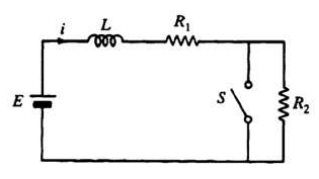

#### **Solución por Lagrange**
---
La única fuerza externa es una fuente de voltaje

$Q=V$

$q=q$

$q̇=q̇$

Como no hay capacitores

$U=0$

La energía cinética corresponde al único inductor del sistema

$T=0.5Lq̇^2$

Como para $t>0$ el switch está cerrado, solo tenemos una fuerza dicipativa, correspondiente a la resistencia $R_1$

$P=0.5R_1q̇^2$

---

Aplicando
$$
\frac{d}{dt}(\frac{∂L}{∂q̇})-\frac{∂L}{∂q}+\frac{∂P}{∂q̇}=Q
$$

Tenemos como resultado

$$
Lq̈+R_1q̇=V
$$

In [8]:
def LagrangeP4(w, t, L, R1, V):
    dw = np.zeros(2)

    dw[0] = w[1]
    dw[1] = (V-R1*w[1])/L

    return dw

In [9]:
@interact(
    L=(0.1, 10, 0.1),
    R1=(1, 100, 1),
    V=(-12, 12, 0.1)
)
def simulacion(L=1, R1=10, V=5):

    tau = L / R1 if R1 != 0 else 1
    t = np.linspace(0, 5*tau, 1000)
    w0 = [0, 0]

    sol = sci.integrate.odeint(LagrangeP4, w0, t, args=(L, R1, V))

    q = sol[:,0]
    i = sol[:,1]

    plt.figure(figsize=(8,4))
    plt.plot(t, q, label='Carga q(t)')
    plt.plot(t, i, label='Corriente i(t)')
    plt.title(f"Respuesta RL (tau = {tau:.4f} s)")
    plt.xlabel("Tiempo")
    plt.ylabel("Magnitud")
    plt.legend()
    plt.grid()
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='L', max=10.0, min=0.1), IntSlider(value=10, descript…

## 5
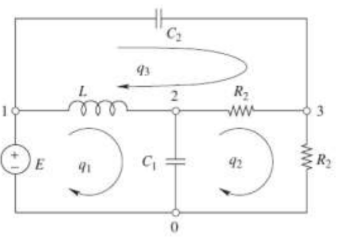

falta

In [10]:
def LagrangeP5(w, t, L, R, V, C1, C2):
    dw = np.zeros(6)

    dw[0] = w[1]
    dw[1] = (R*(w[5]-w[2]) - C2*w[4] + C1*(w[0]-w[1]))/(2*L)
    dw[2] = w[3]
    dw[3] = 0
    dw[4] = w[5]
    dw[5] = (C1*(w[0]-w[3]) - R*(w[5]-w[3]) + C2*w[4])/(2*L)

    return dw

## 6

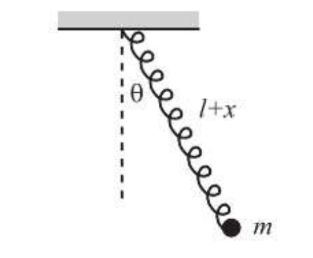

## Péndulo con resorte (coordenadas \(x, \theta\))

Sea la longitud del resorte:
$$
r = l + x
$$

---

## Energía cinética

$$
T = \frac{1}{2}m\left(\dot{x}^2 + (l + x)^2 \dot{\theta}^2 \right)
$$

---

## Energía potencial

### Resorte:
$$
U_{resorte} = \frac{1}{2}k x^2
$$

### Gravitacional:
$$
U_g = -mg (l + x)\cos\theta
$$

### Total:
$$
U = \frac{1}{2}k x^2 - mg (l + x)\cos\theta
$$

---

## Lagrangiano

$$
\mathcal{L} = T - U
$$

$$
\mathcal{L} = \frac{1}{2}m\left(\dot{x}^2 + (l + x)^2 \dot{\theta}^2 \right)
- \frac{1}{2}k x^2 + mg (l + x)\cos\theta
$$

---

## Ecuaciones de Euler-Lagrange

### Para x:

$$
\frac{d}{dt}\left( m\dot{x} \right) - \left[ m(l + x)\dot{\theta}^2 - kx + mg\cos\theta \right] = 0
$$

Resultado:

$$
m\ddot{x} = m(l + x)\dot{\theta}^2 - kx + mg\cos\theta
$$

---

### Para $\theta$ :

$$
\frac{d}{dt}\left( m(l + x)^2 \dot{\theta} \right) + mg(l + x)\sin\theta = 0
$$

Desarrollando:

$$
m(l + x)^2 \ddot{\theta} + 2m(l + x)\dot{x}\dot{\theta} + mg(l + x)\sin\theta = 0
$$

---

## Sistema final

$$
{
\ddot{x} = (l + x)\dot{\theta}^2 - \frac{k}{m}x + g\cos\theta
}
$$

$$
{
\ddot{\theta} = -\frac{2\dot{x}\dot{\theta}}{l + x} - \frac{g}{l + x}\sin\theta
}
$$

In [11]:
def LagrangeP6(w, t, m, k, l, g):
    dw = np.zeros(4)

    # Variables de estado
    # w[0] = x
    # w[1] = x_dot
    # w[2] = theta
    # w[3] = theta_dot

    dw[0] = w[1]

    dw[1] = (l + w[0])*(w[3]**2) - (k/m)*w[0] + g*np.cos(w[2])

    dw[2] = w[3]

    dw[3] = -2*w[1]*w[3]/(l + w[0]) - (g/(l + w[0]))*np.sin(w[2])

    return dw

In [12]:
@interact(
    m=(0.1, 5, 0.1),
    k=(0.1, 50, 0.5),
    l=(0.1, 5, 0.1),
    g=(1, 20, 0.5)
)
def simulacion(m=1, k=10, l=1, g=9.81):

    # Escala de tiempo característica (tipo intuición física)
    tau = np.sqrt(l/g)
    
    t = np.linspace(0, 10*tau, 1000)

    # Condiciones iniciales: [x, x_dot, theta, theta_dot]
    w0 = [0.1, 0, 0.2, 0]

    sol = sci.integrate.odeint(LagrangeP6, w0, t, args=(m, k, l, g))

    x = sol[:,0]
    x_dot = sol[:,1]
    theta = sol[:,2]
    theta_dot = sol[:,3]

    plt.figure(figsize=(10,5))
    
    plt.subplot(1,2,1)
    plt.plot(t, x, label='x(t)')
    plt.plot(t, theta, label='θ(t)')
    plt.xlabel("Tiempo")
    plt.ylabel("Posición")
    plt.legend()
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(t, x_dot, label='ẋ(t)')
    plt.plot(t, theta_dot, label='θ̇(t)')
    plt.xlabel("Tiempo")
    plt.ylabel("Velocidad")
    plt.legend()
    plt.grid()

    plt.suptitle(f"Péndulo con resorte (τ ≈ {tau:.3f} s)")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='m', max=5.0, min=0.1), FloatSlider(value=10.0, descr…